In [ ]:
import pedpy
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely import from_wkt
import json
from pedpy import compute_voronoi_density
from pedpy import compute_individual_voronoi_polygons
from pathlib import Path
from pedpy import (
    Cutoff,
    SpeedCalculation,
    compute_individual_speed,
    compute_individual_voronoi_polygons,
)
from pedpy import FRAME_COL, ID_COL, POINT_COL, DENSITY_COL
from pedpy import Cutoff
from pedpy import plot_voronoi_cells
import seaborn as sns

In [83]:
def read_json_file(file_path):
    with open(file_path, "r") as file:
        data = json.load(file)
    return data

In [ ]:
# geometry = from_wkt(
#    "POLYGON ((-8.88 -7.63, 8.3 -7.63, 8.3 27.95, -8.88 27.95, -8.88 -7.63), (-3.54 -1.13, -3.57 19.57, -1.52 19.57, -1.37 19.71, -1.37 21.09, -1.52 21.23, -1.67 21.23, -1.67 21.18, -1.545 21.18, -1.4200000000000002 21.065, -1.4200000000000002 19.735, -1.545 19.62, -3.6199999999999997 19.62, -3.59 -1.13, -3.54 -1.13), (3.57 -0.89, 3.64 19.64, 1.47 19.57, 1.32 19.71, 1.32 21.09, 1.47 21.23, 1.62 21.23, 1.62 21.18, 1.4949999999999999 21.18, 1.37 21.065, 1.37 19.735, 1.4949999999999999 19.62, 3.69 19.69, 3.6199999999999997 -0.89, 3.57 -0.89), (0.67 19.57, 0.82 19.71, 0.82 21.09, 0.67 21.23, 0.38 21.23, 0.23 21.09, 0.23 19.71, 0.38 19.57, 0.67 19.57), (-0.42 19.57, -0.27 19.71, -0.27 21.09, -0.42 21.23, -0.72 21.23, -0.87 21.09, -0.87 19.71, -0.72 19.57, -0.42 19.57))"
# )
# geometry = from_wkt(
#    "POLYGON ((-8.88 -7.63, 8.3 -7.63, 8.3 27.95, -8.88 27.95, -8.88 -7.63), (-3.54 -1.13, -3.57 19.57, -1.52 19.57, -1.37 19.71,  -0.87 19.71, -0.72 19.57, -0.42 19.57, -0.27 19.71, -0.27 21.09, -0.42 21.23, -0.72 21.23, -0.87 21.09, -1.37 21.09, -1.52 21.23, -1.67 21.23, -1.67 21.18, -1.545 21.18, -1.4200000000000002 21.065, -1.4200000000000002 19.735, -1.545 19.62, -3.6199999999999997 19.62, -3.59 -1.13, -3.54 -1.13), (3.57 -0.89, 3.64 19.64, 1.47 19.57, 1.32 19.71, 0.82 19.71, 0.67 19.57, 0.38 19.57, 0.23 19.71, 0.23 21.09, 0.38 21.23, 0.67 21.23, 0.82 21.09, 1.32 21.09, 1.47 21.23, 1.62 21.23, 1.62 21.18, 1.4949999999999999 21.18, 1.37 21.065, 1.37 19.735, 1.4949999999999999 19.62, 3.69 19.69, 3.6199999999999997 -0.89, 3.57 -0.89))"
# )
geometry = from_wkt(
    "POLYGON ((-8.88 -7.63, 8.3 -7.63, 8.3 27.95, -8.88 27.95, -8.88 -7.63), (-3.54 -1.13, -3.57 19.57, -1.52 19.57, -1.37 19.71,  -0.87 19.71, -0.72 19.57, -0.42 19.57,  -0.42 21.23, -0.72 21.23, -0.87 21.09, -1.37 21.09, -1.52 21.23, -1.67 21.23, -1.67 21.18, -1.545 21.18, -1.4200000000000002 21.065, -1.4200000000000002 19.735, -1.545 19.62, -3.6199999999999997 19.62, -3.59 -1.13, -3.54 -1.13), (3.57 -0.89, 3.64 19.64, 1.47 19.57, 1.32 19.71, 0.82 19.71, 0.67 19.57, 0.38 19.57,  0.38 21.23, 0.67 21.23, 0.82 21.09, 1.32 21.09, 1.47 21.23, 1.62 21.23, 1.62 21.18, 1.4949999999999999 21.18, 1.37 21.065, 1.37 19.735, 1.4949999999999999 19.62, 3.69 19.69, 3.6199999999999997 -0.89, 3.57 -0.89))"
)
walkable_area = pedpy.WalkableArea(geometry)

inifile = "files/inifile_1C070.json"
data = read_json_file(inifile)
measurement_line = pedpy.MeasurementLine(data["measurement_line"]["vertices"])
measurement_area = pedpy.MeasurementArea(data["measurement_area"]["vertices"])
measurement_area = pedpy.MeasurementArea(
    [[-0.72, 17], [0.67, 17], [0.67, 16], [-0.72, 16]]
)

# pedpy.plot_measurement_setup(traj=traj, walkable_area=walkabel_area, measurement_lines=[measurement_line], measurement_areas=[measurement_area]).axis('equal')

In [ ]:
def process_experiment_file(
    filename,
    walkable_area,
    fps=50,
    polygon_cutoff_radius=1.0,
    polygon_quad_segments=3,
    title=None,
    file_type="experiment",
):

    if file_type == "experiment":
        if not title:
            title = filename.split("_")[1].capitalize()
        df = pd.read_csv(
            filename, sep="\t", names=["id", "frame", "x", "y", "z", "m"], comment="#"
        )
        traj = pedpy.TrajectoryData(df, frame_rate=fps)
        print(filename, traj.frame_rate)
    elif file_type == "simulation":
        traj = pedpy.load_trajectory_from_jupedsim_sqlite(filename)
        df = traj.data
        print(filename, traj.frame_rate)

    print(f"Processing experiment: {title}")

    # --- Crossing Information Calculation ---
    # Filter rows where pedestrians have crossed (e.g., y >= 20)
    df_crossed = df[df["y"] >= 20].copy()

    # For each pedestrian (id), get the first frame where they cross.
    crossing_frames = df_crossed.groupby("id")["frame"].min().rename("crossing_frame")

    # Sort crossing frames to determine the order.
    crossing_frames_sorted = crossing_frames.sort_values()

    # Create a series that indicates crossing order (1 for first, 2 for second, etc.)
    crossing_order = pd.Series(
        range(1, len(crossing_frames_sorted) + 1),
        index=crossing_frames_sorted.index,
        name="crossing_order",
    )

    crossing_info = pd.concat([crossing_frames, crossing_order], axis=1)

    # --- Voronoi Polygon and Density Computation ---
    # Compute individual Voronoi polygons; ensure 'walkable_area' is defined properly.
    individual = compute_individual_voronoi_polygons(
        traj_data=traj,
        walkable_area=walkable_area,
        cut_off=Cutoff(
            radius=polygon_cutoff_radius, quad_segments=polygon_quad_segments
        ),
    )

    # Compute mean density over time (group by frame)
    density_over_time = (
        individual.groupby("frame")["density"].mean().rename("mean_individual_density")
    )

    # Compute mean density per agent (group by id)
    density_per_agent = (
        individual.groupby("id")["density"].mean().rename("mean_density_per_agent")
    )

    # Compute polygon area for each individual.
    individual["area"] = individual["polygon"].apply(lambda poly: poly.area)

    # Compute mean polygon area per agent.
    area_per_agent = (
        individual.groupby("id")["area"].mean().rename("mean_area_per_agent")
    )

    # --- Merging the Data ---
    # Create DataFrames from Series
    df_order = crossing_order.to_frame(name="order")
    df_density = density_per_agent.to_frame(name="density")
    df_area = area_per_agent.to_frame()

    # Merge on the 'id' index (make sure all series are indexed by id)
    df_merged = df_order.join(df_density, how="inner").join(df_area, how="inner")

    return df_merged, density_over_time, crossing_info, individual, title

In [ ]:
experiment_file_low = "../trajectories_croma/1C070_cam6_cam5_frameshift0_Combined.txt"
experiment_file_high = "../trajectories_croma/2C070_cam6_cam5_frameshift0_Combined.txt"

# Process one experiment file (low motivation)
df_merged_low, density_over_time_low, crossing_info_low, individual_low, title_low = (
    process_experiment_file(experiment_file_low, walkable_area)
)

# Process another experiment file (high motivation)
(
    df_merged_high,
    density_over_time_high,
    crossing_info_high,
    individual_high,
    title_high,
) = process_experiment_file(experiment_file_high, walkable_area)

Processing experiment: Croma/1c070
Processing experiment: Croma/2c070


In [ ]:
date = "2025-02-14_16-16-33"
simulation_file = Path(f"files/variations/m1C070_base_{date}.sqlite")

(
    df_merged_simulation,
    density_over_time_simulation,
    crossing_info_simulation,
    individual_simulation,
    title_simulation,
) = process_experiment_file(
    simulation_file, walkable_area, file_type="simulation", title="Simulation"
)

files/variations/m1C070_base_2025-02-14_16-02-15.sqlite 20.0
Processing experiment: Simulation


Processing experiment: Simulation


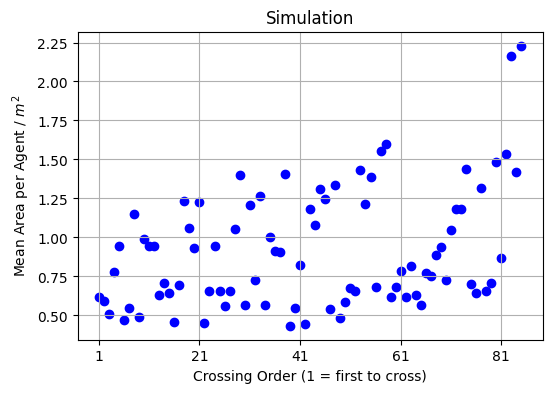

In [113]:
plt.figure(figsize=(6, 4))
plt.scatter(
    df_merged_simulation["order"],
    df_merged_simulation["mean_area_per_agent"],
    color="blue",
)
print(f"Processing experiment: {title_simulation}")
plt.xlabel("Crossing Order (1 = first to cross)")
plt.ylabel(r"Mean Area per Agent / $m^2$")
plt.title(title_simulation)
max_order = df_merged_simulation["order"].max()
plt.xticks(range(1, max_order + 1, 20))
plt.grid(True)
plt.show()

Processing experiment: Croma/2c070


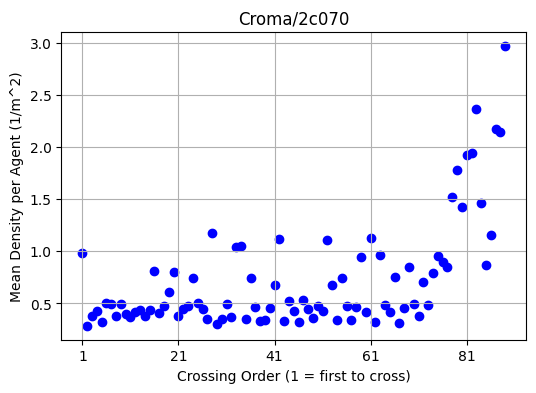

In [112]:
plt.figure(figsize=(6, 4))
plt.scatter(
    df_merged_high["order"], df_merged_high["mean_area_per_agent"], color="blue"
)
print(f"Processing experiment: {title_high}")
plt.xlabel("Crossing Order (1 = first to cross)")
plt.ylabel("Mean Density per Agent (1/m^2)")
plt.title(title_high)
max_order = df_merged_simulation["order"].max()
plt.xticks(range(1, max_order + 1, 20))
plt.grid(True)
plt.show()

Processing experiment: Croma/1c070


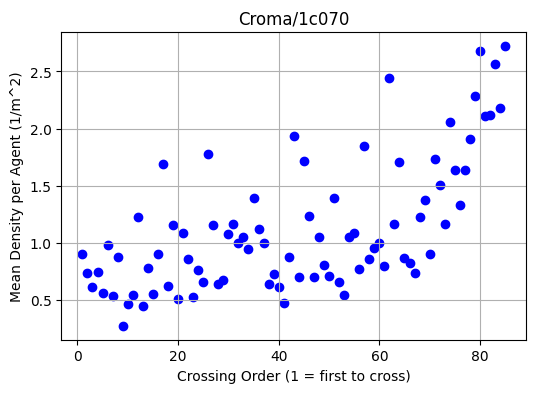

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(df_merged_low["order"], df_merged_low["mean_area_per_agent"], color="blue")
print(f"Processing experiment: {title_low}")
plt.xlabel("Crossing Order (1 = first to cross)")
plt.ylabel("Mean Density per Agent (1/m^2)")
plt.title(title_low)
max_order = df_merged_simulation["order"].max()
plt.xticks(range(1, max_order + 1, 20))
plt.grid(True)
plt.show()

In [ ]:
def plot_density_distribution(density_over_time, title, palette="husl"):
    # Set the color palette
    sns.set_palette(palette)

    # Create figure and axis objects with larger figure size and adjust the layout
    fig = plt.figure(figsize=(12, 6))
    # Create a gridspec layout with extra space on the right
    gs = fig.add_gridspec(1, 2, width_ratios=[4, 1])
    ax = fig.add_subplot(gs[0])

    # Plot histogram with KDE overlay
    sns.histplot(
        data=density_over_time,
        kde=True,
        bins=30,
        color="#3498db",
        fill=True,
        alpha=0.6,
        linewidth=2,
        stat="density",
        ax=ax,
    )

    # Enhance the plot styling
    ax.set_xlabel("Mean Individual Density (1/m²)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Density", fontsize=12, fontweight="bold")
    ax.set_title(
        f"Distribution of {title} Density Over Time",
        fontsize=14,
        fontweight="bold",
        pad=20,
    )

    # Customize grid
    ax.grid(True, linestyle="--", alpha=0.7)

    # Create a text box for statistics and legend in the right subplot
    stats_ax = fig.add_subplot(gs[1])
    stats_ax.axis("off")

    plt.tight_layout()
    return fig

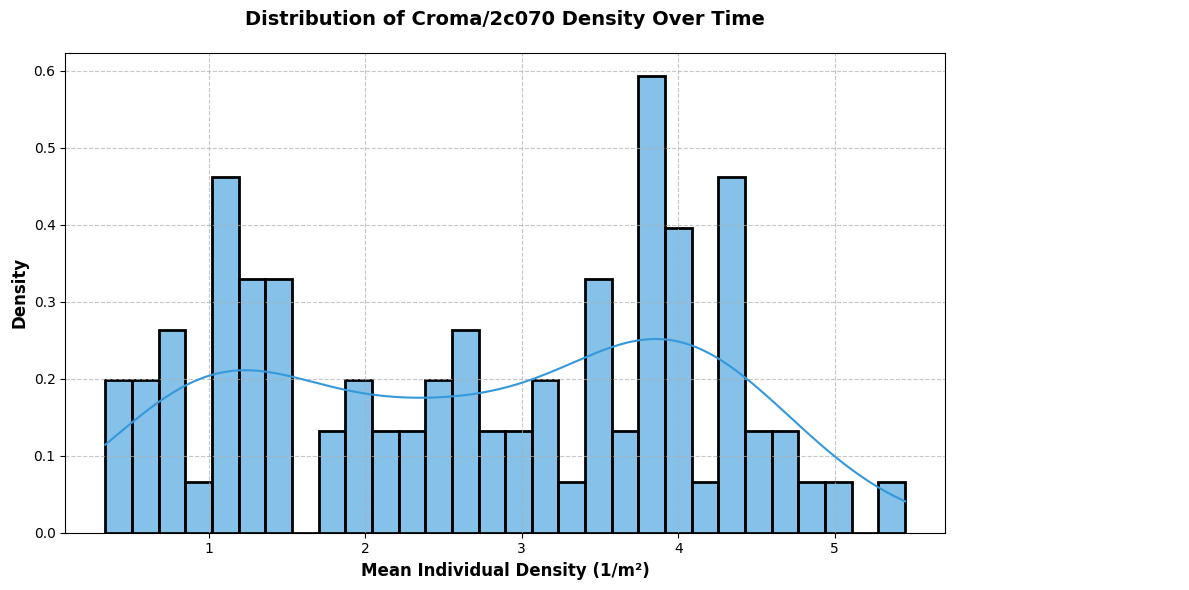

In [90]:
fig_high = plot_density_distribution(df_merged_high["density"], title_high)

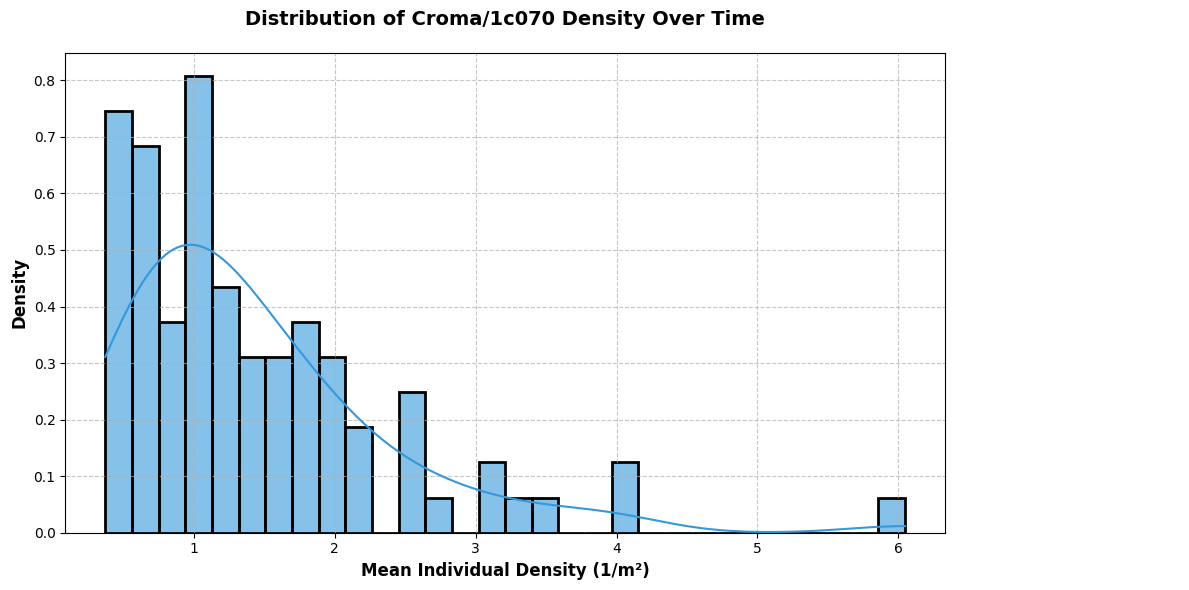

In [91]:
fig_low = plot_density_distribution(df_merged_low["density"], title_low)

In [ ]:
import statsmodels.api as sm

X = df_merged_low["order"]
y = df_merged_low["mean_area_per_agent"]

# Add constant for intercept
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()
print(model.summary())

                             OLS Regression Results                            
Dep. Variable:     mean_area_per_agent   R-squared:                       0.409
Model:                             OLS   Adj. R-squared:                  0.401
Method:                  Least Squares   F-statistic:                     57.34
Date:                 Fri, 14 Feb 2025   Prob (F-statistic):           4.60e-11
Time:                         09:20:14   Log-Likelihood:                -50.366
No. Observations:                   85   AIC:                             104.7
Df Residuals:                       83   BIC:                             109.6
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4905      0.097      5.06

In [95]:
len(df_merged_high)

89